In [1]:
import os
from pathlib import Path

from astropy.table import Table, join
import numpy as np
from numpy.lib.recfunctions import structured_to_unstructured
import matplotlib.pyplot as plt

from quasarnp.utils import absorber_IGM

In [2]:
c_thresh = 0.95
n_thresh = 1

line_names = ["LYA", "CIV", "CIII", "MgII", "HBETA", "HALPHA"]
line_and_wave = ["LYA", "CIV(1548)", "CIII(1909)", "MgII(2796)", "Hbeta", "Halpha"]
line_wavelengths = [absorber_IGM[k]for k in line_and_wave]
c_names = [f"C_{l}" for l in line_names]

In [3]:
SCRATCH = Path("/pscratch/sd/d/dylang")
table_loc = SCRATCH / "qnp" / "dr12_all_guadalupe.csv"

In [4]:
def calc_entropy(confidence):
    H = confidence * np.log(confidence)
    H = np.where(confidence == 0, 0, H)
    return -np.sum(H, axis=1)

In [5]:
old_tbl = Table.read(table_loc)
old_tbl

TARGETID,TILEID,EXPID,C_LYA,C_CIV,C_CIII,C_MgII,C_HBETA,C_HALPHA,C_CIV_BAL,Z_LYA,Z_CIV,Z_CIII,Z_MgII,Z_HBETA,Z_HALPHA,Z_CIV_BAL,ZBEST
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627758518669118,1000,89031,0.0016741289942648458,0.04020673444509168,0.92106447396715,0.9417525981257873,3.7649795831047e-05,3.99492223114839e-05,1.7844302480932927e-05,2.8402121837990126,1.519256155702168,1.483717641839097,1.496563806623815,0.24593487054342988,0.042819886712210264,4.474599877185332,1.496563806623815
39627764562658182,1000,89031,1.513061519365129e-06,8.044658981381805e-06,2.5685893946577576e-06,6.156486392023656e-06,3.774063813109704e-06,1.6390029416257317e-05,2.2142878292050416e-06,7.103563988016338,1.4042756767111815,1.100412430439854,1.6834193192018136,0.9739357915777567,0.13892008254105415,2.879963211840485,0.13892008254105415
39627764562660466,1000,89031,0.999999959073144,0.9999999687015929,0.9999999215870486,6.154147564047898e-06,2.135690120287605e-05,4.946267475565533e-06,0.0003861174031670185,3.2592381456945683,3.2614181609636983,3.2612887149494894,0.36890734007405634,0.17076632291093818,0.2560947327736458,3.2365810630177947,3.2614181609636983
39627764566852122,1000,89031,0.0049681788976327365,0.00884003976666149,0.0003201414947522075,0.0002849358570249137,3.942677882887877e-06,1.186172399756724e-06,6.771197160552499e-05,2.6419373888890694,2.645754894367178,2.6263109229314847,2.1435270342972563,0.1358009720789184,-0.4321829620446319,2.6173846860058405,2.645754894367178
39627764566854344,1000,89031,0.0020933590329048585,0.0005639932024836017,0.04024205247576325,0.29953295657588036,0.0024083175153189283,2.4187387630995828e-05,0.0003076331477626968,3.2842232553847373,3.297852566818575,0.9337117375881554,0.8746240726049788,0.8782885776340712,-0.16486029699232352,2.3919880438430448,0.8746240726049788
616088516866081489,1000,89031,5.8787908828663095e-05,0.02568972695040607,0.0020402456056190666,0.00027506263856681793,1.047969110705099e-05,4.761103542108664e-06,5.975360591380792e-06,2.8540882805236536,1.830841953577853,1.7100834002553191,1.1147512713268606,0.1718415148027177,0.47102313035259,3.9263872377290214,1.830841953577853
39627764562662455,1000,89031,2.3920418943096385e-05,8.965374243326943e-05,0.00021224030772085307,5.938840785574797e-05,3.0254294675890756e-05,2.4899231206731486e-06,1.0637010129516393e-05,2.8864349077729607,2.6473678375714407,2.0874264059924394,2.103122213505893,0.7941669918161494,-0.07345602795785933,2.570874867277212,2.0874264059924394
39627764562661595,1000,89031,0.00013446391880997898,0.0003660036037435596,0.000318522599190017,0.0006131035081101719,2.5771919251019317e-05,1.3566940497927086e-05,6.590445009797148e-05,2.358998670523132,2.365862007914479,2.4223777030907057,2.406533197059461,0.6776892683461382,0.45041612005925225,2.366439077546354,2.406533197059461
39627758518669735,1000,89031,3.6372325124422887e-06,3.327423744624769e-05,8.632778715466638e-06,1.7744039851382145e-05,3.43106396967973e-05,9.034850222669772e-07,3.6289697190574215e-06,3.558393968950341,1.8681005506568038,1.092438851122815,0.997997512137939,0.8075435202369343,-0.07809355861906553,2.879986526863198,0.8075435202369343


In [6]:
c_line = structured_to_unstructured(np.asarray(old_tbl[c_names]))
is_qso_old = np.sum(c_line > c_thresh, axis=1) >= n_thresh
old_tbl.add_column(is_qso_old, name="IS_QSO")

In [7]:
mult_tids, c = np.unique(old_tbl["TARGETID"], return_counts=True)
mult_exps = mult_tids[c > 1]
n_exp_per_tid = c[c > 1]

In [8]:
old_mult_tbl = old_tbl[np.isin(old_tbl["TARGETID"], mult_exps)]
old_mult_tbl

TARGETID,TILEID,EXPID,C_LYA,C_CIV,C_CIII,C_MgII,C_HBETA,C_HALPHA,C_CIV_BAL,Z_LYA,Z_CIV,Z_CIII,Z_MgII,Z_HBETA,Z_HALPHA,Z_CIV_BAL,ZBEST,IS_QSO
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool
39627764566852241,1000,89031,0.007098846056684754,0.0001135718347812786,2.6207208829847168e-05,1.544854680572663e-05,2.733422211695127e-07,4.432359789255273e-08,5.753375545256393e-07,2.070282636308526,2.089482420377897,2.1516673171997023,1.9584856872363448,0.8182784188793424,-0.18508288638349257,2.0440956252680027,2.070282636308526,False
39627776646451869,1000,89031,5.389503746344866e-06,8.595281433048681e-05,1.0369236873313362e-05,1.490505823978687e-05,6.618495862368955e-07,1.0773394678575907e-07,1.3899016824995798e-05,2.0692363379311103,2.0680294953033473,1.0857621155525523,1.853891940881946,0.5508676043183152,-0.4480235709451823,1.8430991459952777,2.0680294953033473,False
39627758527057910,1000,89031,7.495717056829571e-06,0.00016006085359536522,0.0004210786073562941,0.00022913238093903368,6.303967347235066e-06,1.9616400501770847e-06,2.934647611593226e-05,2.563457778729038,1.8281965771696274,1.0991675509920436,1.7553111018888767,0.6748607363881971,-0.22764822593954448,1.8837484570197485,1.0991675509920436,False
39627764566854878,1000,89031,2.4680422911608657e-05,0.00031277824102913637,0.008764624417166928,0.001068682761110328,1.0374178403152334e-06,1.1490384867355562e-06,9.98985312552717e-06,2.343071589141408,1.623306424942017,1.6460279930961916,2.3547379900986978,0.9627720846775825,0.4060935816180504,2.520451841923984,1.6460279930961916,False
39627758518669566,1000,89031,5.540738985908805e-06,7.616825137145734e-06,5.433587817641138e-05,8.698685853421594e-05,7.764207788527387e-07,1.8352785375682424e-06,0.0001352918158224262,2.600595812020635,2.6069755263396504,1.0983693862502628,1.6872976570441214,0.5187409756813237,0.48091715937659085,2.8150381672935962,1.6872976570441214,False
39627758518668087,1000,89031,1.4581165747660388e-07,2.94945567837069e-05,2.944616319452462e-05,3.8498530872315356e-05,9.299470929577965e-07,1.201226495533646e-07,5.740331722258411e-05,6.686061730980243,1.792224885211314,1.0838941185580389,1.7569999897347333,0.5334760684265853,-0.09532959610208747,1.8188354706816794,1.7569999897347333,False
39627764566857060,1000,89031,0.00010833033598249798,4.716423035706489e-05,0.0001743895064782804,0.0003819101042265156,2.7784340842719326e-06,4.359595721004351e-06,3.908726375884204e-05,2.9742374365737216,1.633279718589177,1.6659701474230433,2.40140803870528,0.977838828491961,0.3900988321200358,2.525929754149893,2.40140803870528,False
39627764558464444,1000,89031,3.557797605916407e-06,0.00017728271217969658,0.00036295879950974343,5.837589029283548e-05,3.2269696596609804e-06,1.4047076979815714e-06,4.737417262757908e-06,5.123475836653638,1.434062909782691,1.5410087337914797,1.5152807348226935,0.9551434747349259,-0.34816240814452537,2.0577257440970906,1.5410087337914797,False
39627770598265548,1000,89031,1.9095696238282525e-06,8.771593680984012e-05,9.870599377594668e-06,1.366588484420522e-05,5.2204794706093814e-06,5.768568431123618e-06,1.7883036172678225e-06,5.131937999992606,1.7898940179307736,1.8753391696833632,1.477649113487995,0.4356317155361289,0.13537452001633254,5.159527361316987,1.7898940179307736,False


In [9]:
grouped_table_old = old_mult_tbl["TARGETID", "IS_QSO"].group_by("TARGETID")
_, counts_old = np.unique(grouped_table_old["TARGETID"], return_counts=True)
grouped_table_old = grouped_table_old.groups.aggregate(np.sum)
grouped_table_old.add_column(counts_old - grouped_table_old["IS_QSO"], name="NOT_QSO")
grouped_table_old

TARGETID,IS_QSO,NOT_QSO
int64,int64,int64
-809809526,0,2
-809809510,0,2
-809809491,0,2
-809809472,0,2
-809809458,0,2
-809809454,0,2
-809809431,0,2
-809809429,0,2
-809809428,0,2


In [10]:
confs_old = structured_to_unstructured(np.asarray(grouped_table_old["IS_QSO", "NOT_QSO"])) / counts_old[:, None]
H_old = calc_entropy(confs_old)

/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence)
/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence)


In [11]:
new_loc = SCRATCH / "qnp" / "qnet_linear_v2_guadalupe-1.csv"

In [12]:
new_tbl = Table.read(new_loc)
new_tbl

TARGETID,TILEID,EXPID,C_LYA,C_CIV,C_CIII,C_MgII,C_HBETA,C_HALPHA,C_CIV_BAL,Z_LYA,Z_CIV,Z_CIII,Z_MgII,Z_HBETA,Z_HALPHA,Z_CIV_BAL,ZBEST
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627758518669118,1000,89031,0.003036657115444541,0.9943460822105408,0.9975751042366028,0.9897522926330566,0.0055313208140432835,0.0026786725502461195,0.9478951692581177,2.520978572856931,1.4921954448791142,1.5199637539265134,1.501413994999825,0.7208673453975039,0.44112954108422,2.5397914044608068,1.5199637539265134
39627764562658182,1000,89031,0.001077878288924694,0.0008136352407746017,0.0013011544942855835,0.0007590942550450563,0.001735839992761612,0.0009983344934880733,0.8775632977485657,4.646744359627458,2.4098917543895646,2.522973236206906,1.0512781232365742,0.10365055362474318,0.049473711936943277,3.8817558201426063,0.10365055362474318
39627764562660466,1000,89031,0.9991744160652161,0.9979630708694458,0.9974911212921143,0.04036508500576019,0.011107354424893856,0.01337712537497282,0.8803526759147644,3.2533031212294716,3.2423362742881867,3.2378919748112507,2.397947764243098,0.03637152533966592,0.048050637521075856,3.21015730040639,3.2533031212294716
39627764566852122,1000,89031,0.00020696403225883842,0.00024158450833056122,0.00029707630164921284,0.0007098844507709146,0.0007018081960268319,0.000521043490152806,0.9107405543327332,4.654442032820339,2.677000237328857,1.0385325822380596,1.0351567102110537,0.9807983853938789,0.1310741255807173,2.518218894812982,1.0351567102110537
39627764566854344,1000,89031,0.006055294536054134,0.0018103676848113537,0.42884522676467896,0.25079432129859924,0.3744962513446808,0.00846405141055584,0.8944257497787476,4.73169890742593,4.195987778025124,0.9341456760633895,0.9135858275620801,0.9002334873697106,0.4433111829499612,4.413486650145846,0.9341456760633895
616088516866081489,1000,89031,0.00020471547031775117,0.000119720098155085,0.00012381382111925632,0.0002462523407302797,0.0003001438162755221,0.00033460475970059633,0.9300235509872437,4.650357075170693,4.533169171280097,1.7872263988929502,0.6160560250955844,0.23582869245498728,0.22990056257726654,2.4861524050519597,0.22990056257726654
39627764562662455,1000,89031,0.0002839507651515305,0.0002263709029648453,0.00017415448382962495,0.000264450820395723,0.00015987273945938796,0.00023912785400170833,0.9031621813774109,3.621440533578042,3.5743307667838033,3.6427174030516527,0.6149533782211043,0.08648120423012617,0.13193312865251805,2.371314444006603,3.621440533578042
39627764562661595,1000,89031,0.00036506567266769707,0.00015351013280451298,0.0003056250570807606,0.00041104306001216173,0.0005485665751621127,0.00012715949560515583,0.913757860660553,2.603773841078277,1.4820071777124069,1.4721733873027194,1.5116146875418028,0.7562947534692914,0.48102282033238764,2.425226893528211,0.7562947534692914
39627758518669735,1000,89031,0.0014999413397163153,0.0011601676233112812,0.0028585162945091724,0.0020412818994373083,0.0019137246999889612,0.0014720570761710405,0.8939838409423828,2.16141327563766,2.3554492001313516,2.257079970050344,2.2304593081449973,0.3707583486731403,0.48619850988092206,2.388566952839366,2.257079970050344


In [13]:
c_line = structured_to_unstructured(np.asarray(new_tbl[c_names]))
is_qso_new = np.sum(c_line > c_thresh, axis=1) >= n_thresh
new_tbl.add_column(is_qso_new, name="IS_QSO")

In [14]:
mult_tids, c = np.unique(new_tbl["TARGETID"], return_counts=True)
mult_exps = mult_tids[c > 1]
n_exp_per_tid = c[c > 1]

In [15]:
new_mult_tbl = new_tbl[np.isin(new_tbl["TARGETID"], mult_exps)]
new_mult_tbl

TARGETID,TILEID,EXPID,C_LYA,C_CIV,C_CIII,C_MgII,C_HBETA,C_HALPHA,C_CIV_BAL,Z_LYA,Z_CIV,Z_CIII,Z_MgII,Z_HBETA,Z_HALPHA,Z_CIV_BAL,ZBEST,IS_QSO
int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool
39627764566852241,1000,89031,0.00017891362949740142,0.00044376656296662986,0.0008391224546357989,0.001374413724988699,0.000619994942098856,0.0004780518065672368,0.9388478994369507,4.162869573691051,1.4770783519532231,1.4598031936530775,1.5149349142941166,0.3798514377374971,0.026090493225839895,2.465897488135802,1.5149349142941166,False
39627776646451869,1000,89031,0.00017451039457228035,0.0003564308281056583,0.00022032194829080254,0.000797045067884028,0.003375404281541705,0.0004412861599121243,0.9453436732292175,4.745962295214745,4.700370797504189,3.061160467041762,0.38340396871265603,0.37271190622629735,0.45132780154996577,2.394053977272131,0.37271190622629735,False
39627758527057910,1000,89031,0.0004258303961250931,0.0007946255500428379,0.0016260984120890498,0.005226218141615391,0.0038540081586688757,0.0014771424466744065,0.9456449151039124,4.746507451530576,4.7040455185865895,1.0595755681990826,1.047858892549678,0.36603138185002737,0.03964567727815149,2.395818914761256,1.047858892549678,False
39627764566854878,1000,89031,0.0003279811644461006,0.00034497896558605134,0.0004488578124437481,0.004758366849273443,0.006679360289126635,0.0030448080506175756,0.9567111730575562,4.647289216416532,4.700608392337896,1.0531017194355896,0.37713034245399135,0.3768084455771896,0.3393424312316695,2.422332775304972,0.3768084455771896,False
39627758518669566,1000,89031,0.000562033150345087,0.000960299395956099,0.0012919805012643337,0.005115820560604334,0.0023784483782947063,0.0007663928554393351,0.9342394471168518,2.513752859862926,1.4696999396452717,1.0551615668037835,1.0458743099653844,0.9728271620493929,0.038972989247633594,2.4113372916694047,1.0458743099653844,False
39627758518668087,1000,89031,0.00022849818924441934,0.00044883598457090557,0.0003262347890995443,0.0014380771899595857,0.003357573878020048,0.00047874863957986236,0.942411482334137,4.7776922657192955,4.701308102920548,1.0473375731505996,1.0314779644138077,0.36956632027885616,0.03673918004065935,2.3733065679223846,0.36956632027885616,False
39627764566857060,1000,89031,0.00030839332612231374,0.00020401865185704082,0.0003674266627058387,0.0016045499360188842,0.003956773318350315,0.0013968046987429261,0.9496867656707764,4.646172016853679,4.700280499846119,1.0523047124652334,0.378109903355746,0.37653229952702905,0.33667054777756467,2.4181933928641066,0.37653229952702905,False
39627764558464444,1000,89031,0.0004311466764193028,0.0006956482538953424,0.0023800511844456196,0.002800561022013426,0.004602257162332535,0.000756149529479444,0.9480825662612915,4.725291780501349,4.700324291708484,1.023701905620206,1.0288240482350526,0.9652985423451197,0.4595275585013048,2.4179268232756357,0.9652985423451197,False
39627770598265548,1000,89031,0.0011867501307278872,0.0013707795878872275,0.0013678708346560597,0.0007594085764139891,0.001462467247620225,0.0009613095317035913,0.8780009150505066,4.657824617845496,2.411333934416266,2.5158541945307404,1.0513361427695194,0.09688846106502291,0.05158513154830646,3.884515980276337,0.09688846106502291,False


In [16]:
grouped_table_new = new_mult_tbl["TARGETID", "IS_QSO"].group_by("TARGETID")
_, counts_new = np.unique(grouped_table_new["TARGETID"], return_counts=True)

grouped_table_new = grouped_table_new.groups.aggregate(np.sum)
grouped_table_new.add_column(counts_new - grouped_table_new["IS_QSO"], name="NOT_QSO")
grouped_table_new

TARGETID,IS_QSO,NOT_QSO
int64,int64,int64
-809809526,0,2
-809809510,0,2
-809809491,0,2
-809809472,0,2
-809809458,0,2
-809809454,0,2
-809809431,0,2
-809809429,0,2
-809809428,0,2


In [17]:
confs_new = structured_to_unstructured(np.asarray(grouped_table_new["IS_QSO", "NOT_QSO"])) / counts_new[:, None]
H_new = calc_entropy(confs_new)

/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence)
/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence)


In [18]:
j = join(new_tbl, old_tbl, ["TARGETID", "EXPID"], table_names=["NEW", "OLD"])


# Difference in Confidence & Redshift

In [19]:
both_qso = j["IS_QSO_NEW"] & j["IS_QSO_OLD"]

In [20]:
line_confusions = {}
for i, k in enumerate(line_and_wave):
    line_confusions[k] = line_wavelengths[i] / np.asarray(line_wavelengths[(i + 1):])

In [21]:
rest_waves = np.asarray(line_wavelengths)
wave_names = np.asarray(line_and_wave)

slopes = np.zeros((len(rest_waves), len(rest_waves)))
intercepts = np.zeros((len(rest_waves), len(rest_waves)))
for i in range(len(rest_waves)):
    for k in range(len(rest_waves)):
        slopes[i, k] = rest_waves[i] / rest_waves[k]
        intercepts[i, k] = (rest_waves[i] - rest_waves[k])  / rest_waves[k]

In [22]:
line_confusions

{'LYA': array([0.7852126 , 0.63689859, 0.43473439, 0.25      , 0.18523648]),
 'CIV(1548)': array([0.81111611, 0.55365183, 0.31838511, 0.23590615]),
 'CIII(1909)': array([0.68258024, 0.39252717, 0.29084141]),
 'MgII(2796)': array([0.57506377, 0.42609117]),
 'Hbeta': array([0.74094594]),
 'Halpha': array([], dtype=float64)}

In [23]:
confusion_nums = np.concatenate(list(line_confusions.values()))
confusion_nums

array([0.7852126 , 0.63689859, 0.43473439, 0.25      , 0.18523648,
       0.81111611, 0.55365183, 0.31838511, 0.23590615, 0.68258024,
       0.39252717, 0.29084141, 0.57506377, 0.42609117, 0.74094594])

0.9968166838317752
5 0.8111161115168484


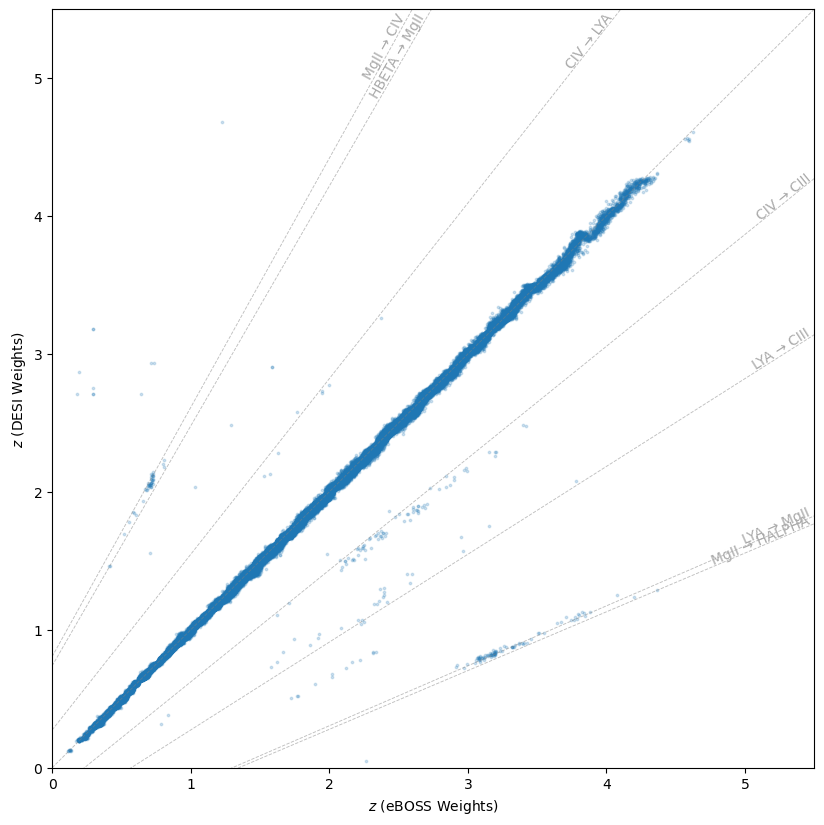

In [24]:
# fig, ax = plt.subplots(figsize=(15, 15))
fig = plt.figure(figsize=(10, 10), layout="constrained")
# plt.rcParams.update({
#     "text.usetex": False,
#     "font.family": "DejaVu Sans"
# })

z_lim = 5.5
ax_scatter = plt.subplot(5, 5, (6, 24))

# only plot points that both networks thought are quasars
both_qso = j["IS_QSO_NEW"] & j["IS_QSO_OLD"]

ax_scatter.scatter(j["ZBEST_OLD"][both_qso], j["ZBEST_NEW"][both_qso], s=3, alpha=0.2)
ax_scatter.plot([0, z_lim], [0, z_lim], c="grey", alpha=0.5, ls="dashed", lw=0.65)
ax_scatter.set(xlim=(0, z_lim), ylim=(0, z_lim))
ax_scatter.set_xlabel("$z$ (eBOSS Weights)")
ax_scatter.set_ylabel("$z$ (DESI Weights)")

# Code for plotting the confusion lines
# xlim = ax_scatter.get_xlim()
# ylim = ax_scatter.get_ylim()
x_1 = np.asarray([0,7])
points = (np.abs(j["ZBEST_OLD"][both_qso] - 1.8) <= 0.3) & (np.abs(j["ZBEST_NEW"][both_qso] - 1) <= 0.2) 

x = j["ZBEST_OLD"][both_qso]#[points]
y = j["ZBEST_NEW"][both_qso]#[points]
slope = np.dot(x, y) / np.dot(x, x)
print(slope)
idx = np.argmin(np.abs(confusion_nums - slope))
print(idx, confusion_nums[idx])

# ax_scatter.plot(x_1, slope * x_1)
ylim = ax_scatter.get_ylim()
xlim = ax_scatter.get_xlim()
x_p = np.asarray([0,7])

confusions = [3, 23, 2, 6, 8, 27, 19] 

for idx in confusions:
    idx_2d = np.unravel_index(idx, shape=slopes.shape)
    
    m = slopes[idx_2d]
    b = intercepts[idx_2d]
      
    text_string = f"{line_names[idx_2d[0]]} → {line_names[idx_2d[1]]}"
    plt.plot(x_p, m * x_p + b, c="grey", alpha=0.5, ls="dashed", lw=0.65)
    
    # Below the 45 the right edge of the line is going to be at the xlimit
    # So use that for the x coord and calculate the y coord, then 
    # offset it above the line
    x_1 = xlim[-1] - 0.04
    y_1 = m * x_1 + 0.05 + b
    
    if y_1 > ylim[-1]:
        y_1 = ylim[-1] - 0.04
        x_1 = (y_1 - b) / m - 0.05
    theta = np.rad2deg(np.arctan(m))
    
    plt.text(x_1, y_1, text_string, ha="right", va="center", rotation_mode="anchor", rotation=theta, c="darkgrey")
    
ax_scatter.set_ylim(ylim)
ax_scatter.set_xlim(xlim)
# plt.grid()

plt.savefig("plots/redshift_diff.jpg", bbox_inches="tight", dpi=256)

In [25]:
confs_old = structured_to_unstructured(np.asarray(grouped_table_old["IS_QSO", "NOT_QSO"])) / counts_old[:, None]
H_old_1 = calc_entropy(confs_old)

/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence)
/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence)


In [26]:
joined_grouped = join(grouped_table_old, grouped_table_new, "TARGETID", table_names=["OLD", "NEW"])

In [27]:
_, counts_join = np.unique(joined_grouped["TARGETID"], return_counts=True)

confs_old = structured_to_unstructured(np.asarray(joined_grouped["IS_QSO_OLD", "NOT_QSO_OLD"])) / counts_old[:, None]
H_old = calc_entropy(confs_old)

confs_new = structured_to_unstructured(np.asarray(joined_grouped["IS_QSO_NEW", "NOT_QSO_NEW"])) / counts_old[:, None]
H_new = calc_entropy(confs_new)

/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence)
/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence)
/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: divide by zero encountered in log
  H = confidence * np.log(confidence)
/tmp/ipykernel_502232/1438353355.py:2: RuntimeWarning: invalid value encountered in multiply
  H = confidence * np.log(confidence)


In [51]:
cmap(0)

np.asarray([0.267004, 0.004874, 0.329415]) * 255

array([68.08602 ,  1.24287 , 84.000825])

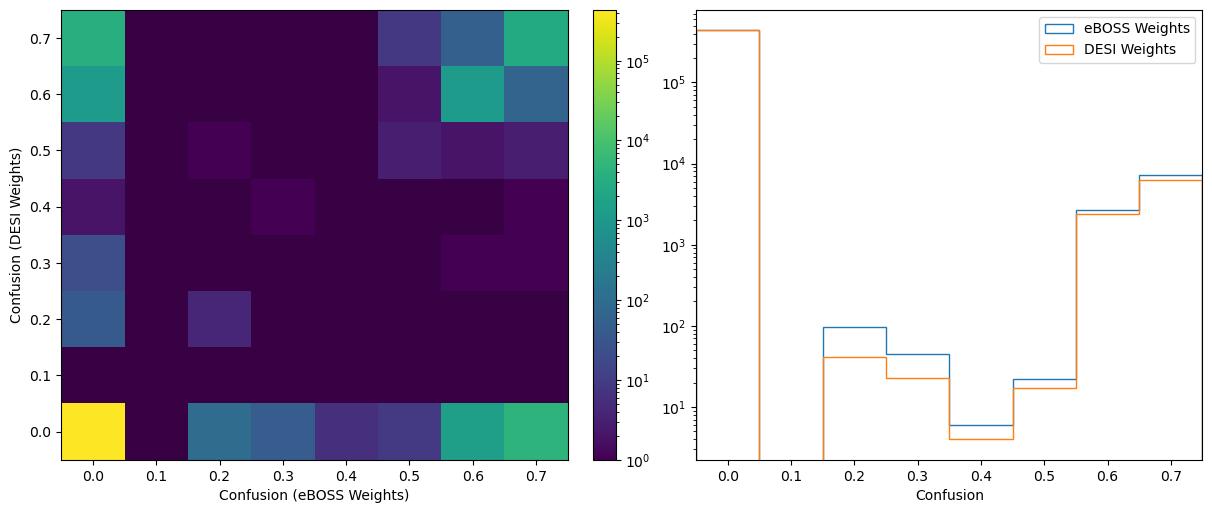

In [55]:
bins = np.arange(-0.05, 0.8, 0.1)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

h = ax[0].hist2d(H_old, H_new, bins=bins, norm="log", cmin=0)

fig.colorbar(h[3], ax=ax[0])

cmap = plt.cm.viridis

ax[0].set_xlabel("Confusion (eBOSS Weights)")
ax[0].set_ylabel("Confusion (DESI Weights)")
ax[0].set_facecolor(np.array([55, 1, 68]) / 255)

n_old, *_ = ax[1].hist(H_old, bins=bins, histtype="step", label="eBOSS Weights")
n_new, *_ = ax[1].hist(H_new, bins=bins, histtype="step", label="DESI Weights")
ax[1].set(yscale="log", xlabel="Confusion", xlim=(bins[0], bins[-1]))
ax[1].legend()
plt.savefig("plots/confusion.jpg", dpi=256, bbox_inches="tight")

In [30]:
mult_tids_joined, c_j = np.unique(j[j["IS_QSO_NEW"]]["TARGETID"], return_counts=True)
mult_exps_joined = mult_tids_joined[c_j > 1]
idcs_joined = np.isin(j[j["IS_QSO_NEW"]]["TARGETID"], mult_exps_joined)

In [31]:
grouped_j = j["TARGETID", "ZBEST_NEW"][j["IS_QSO_NEW"]][idcs_joined].group_by("TARGETID")

# Run the aggregating operations here
std_group_new = grouped_j.groups.aggregate(np.std)
mean_group_new = grouped_j.groups.aggregate(np.mean)
std_group_new.rename_column("ZBEST_NEW", "ZBEST_STD")
mean_group_new.rename_column("ZBEST_NEW", "ZBEST_MEAN")

grouped_j

TARGETID,ZBEST_NEW
int64,float64
39627571582731105,1.0878560480726742
39627571582731105,1.085946969520604
39627571582731334,2.956328227038988
39627571582731334,2.955485307474253
39627571582731444,1.5763461388181765
39627571582731444,1.5760230840978613
39627571591119365,3.229439225495235
39627571591119365,3.2242282821645496
39627571599507732,1.6907587432776134


In [32]:
mult_tids_joined, c_j = np.unique(j[j["IS_QSO_OLD"]]["TARGETID"], return_counts=True)
mult_exps_joined = mult_tids_joined[c_j > 1]
idcs_joined = np.isin(j[j["IS_QSO_OLD"]]["TARGETID"], mult_exps_joined)

In [33]:
grouped_j = j["TARGETID", "ZBEST_OLD"][j["IS_QSO_OLD"]][idcs_joined].group_by("TARGETID")

# Run the aggregating operations here
std_group_old = grouped_j.groups.aggregate(np.std)
mean_group_old = grouped_j.groups.aggregate(np.mean)
std_group_old.rename_column("ZBEST_OLD", "ZBEST_STD")
mean_group_old.rename_column("ZBEST_OLD", "ZBEST_MEAN")

grouped_j

TARGETID,ZBEST_OLD
int64,float64
-809798367,0.9992085159097062
-809798367,2.6316983001684076
-809795243,2.4464748434081742
-809795243,2.3784338245802736
-207286176,3.7932262313373455
-207286176,3.801246690439865
-204188056,3.790055266240415
-204188056,2.076352058741286
39627571582731105,1.1039768839899415


In [34]:
z_mults_new = join(std_group_new, mean_group_new, "TARGETID")
z_mults_new

TARGETID,ZBEST_STD,ZBEST_MEAN
int64,float64,float64
39627571582731105,0.0009545392760350602,1.0869015087966392
39627571582731334,0.000421459782367517,2.9559067672566206
39627571582731444,0.0001615273601576206,1.576184611458019
39627571591119365,0.002605471665342751,3.2268337538298923
39627571599507732,0.0006337131575095967,1.6901250301201038
39627571603702043,0.002419841654891286,1.8517083360181892
39627571607897205,0.0002409566984573619,1.8654158437871338
39627571607897739,0.006461388027421466,0.8662067128691552
39627571612090836,0.0013335489072971995,1.8813672879036787


In [35]:
z_mults_old = join(std_group_old, mean_group_old, "TARGETID")
z_mults_old

TARGETID,ZBEST_STD,ZBEST_MEAN
int64,float64,float64
-809798367,0.8162448921293507,1.815453408039057
-809795243,0.034020509413950295,2.4124543339942237
-207286176,0.004010229551259847,3.7972364608886053
-204188056,0.8568516037495646,2.9332036624908504
39627571582731105,0.0014968606274572416,1.1024800233624843
39627571582731334,0.0006674250743283761,2.964411492697744
39627571582731444,0.004218240951320729,1.5660874923496981
39627571591119365,0.00027535785655574685,3.2172181642583433
39627571599507732,0.0028421705146191023,1.7062252348331381


Text(0.5, 1.0, 'std for z estimates from repeat exposures')

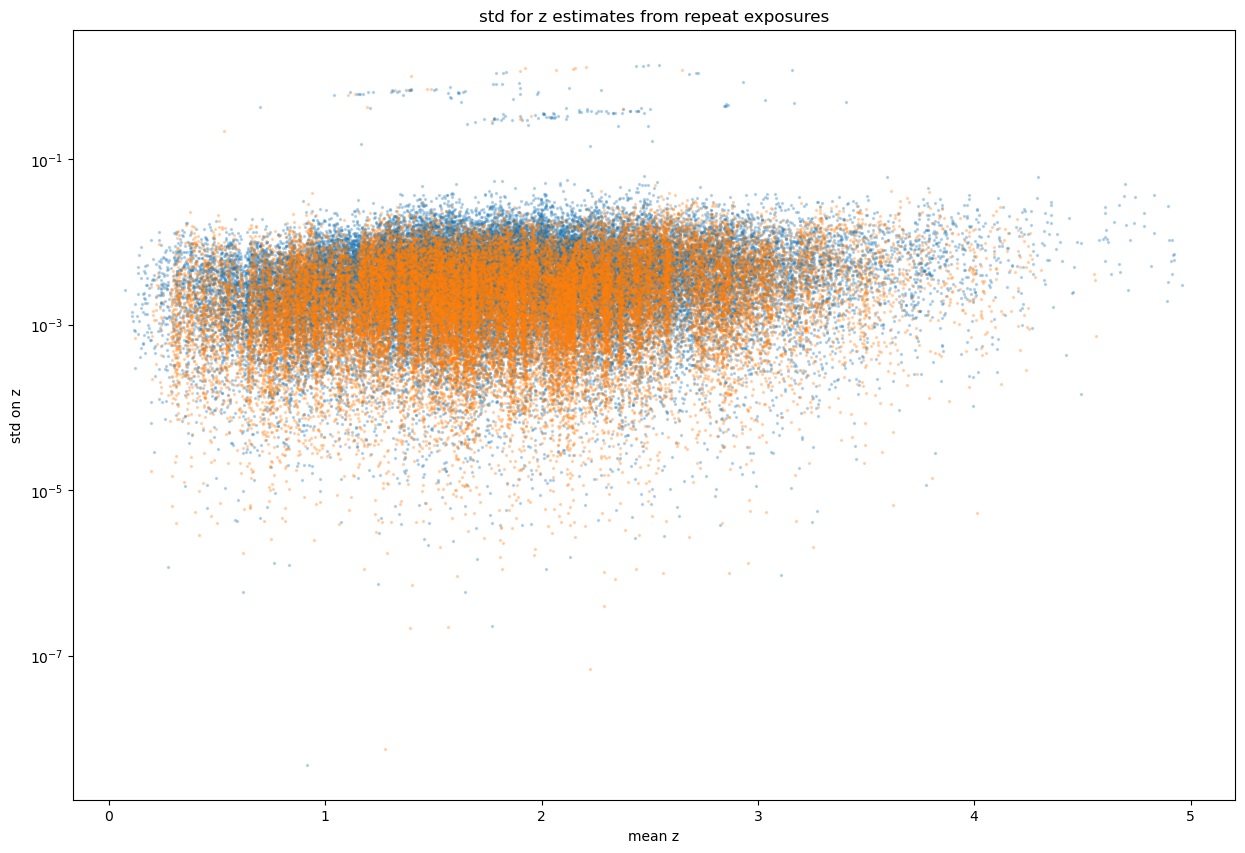

In [36]:
fig, ax = plt.subplots(figsize=(15, 10))

plt.scatter(z_mults_old["ZBEST_MEAN"], z_mults_old["ZBEST_STD"], s=2, alpha=0.25)
plt.scatter(z_mults_new["ZBEST_MEAN"], z_mults_new["ZBEST_STD"], s=2, alpha=0.25)

plt.yscale("log")
plt.xlabel("mean z")
plt.ylabel("std on z")
plt.title("std for z estimates from repeat exposures")
# plt.savefig("plots/std_z.jpg", dpi=256, bbox_inches="tight")

In [111]:
def median_bin(bins, z_tbl):
    median_z_per_bin = []
    for i in range(len(bins) - 1):
        in_bin = (z_tbl["ZBEST_MEAN"] >= bins[i]) & (z_tbl["ZBEST_MEAN"] < bins[i + 1])
        median_z_per_bin.append(np.nanmean(z_tbl["ZBEST_STD"][in_bin]))
    return median_z_per_bin

In [112]:
bins = np.linspace(0, 5, 20)
med_old = median_bin(bins, z_mults_old)
med_new = median_bin(bins, z_mults_new)

/tmp/ipykernel_502232/1161817416.py:5: RuntimeWarning: Mean of empty slice
  median_z_per_bin.append(np.nanmean(z_tbl["ZBEST_STD"][in_bin]))


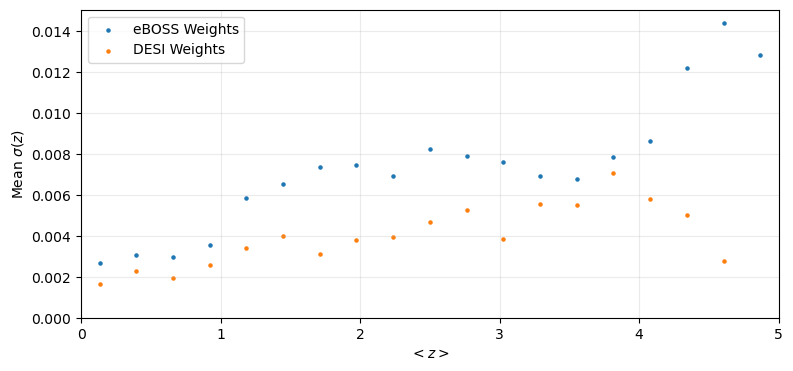

In [114]:
fig, ax = plt.subplots(figsize=(9, 4))
mids = bins[:-1] + np.diff(bins) / 2

plt.scatter(mids, med_old, label="eBOSS Weights", s=5)
plt.scatter(mids, med_new, label="DESI Weights", s=5)

plt.ylabel("Mean $\sigma(z)$")
plt.xlabel("$<z>$")
plt.legend(loc="upper left")
# plt.title("Median Binned $\sigma$ for z Estimates From Repeat Exposures")

plt.ylim(0, None)
plt.xlim(bins[0], bins[-1])
plt.grid(alpha=0.25)

plt.savefig("plots/binned_std_z.jpg", dpi=256, bbox_inches="tight")

In [87]:
from matplotlib.transforms import Bbox

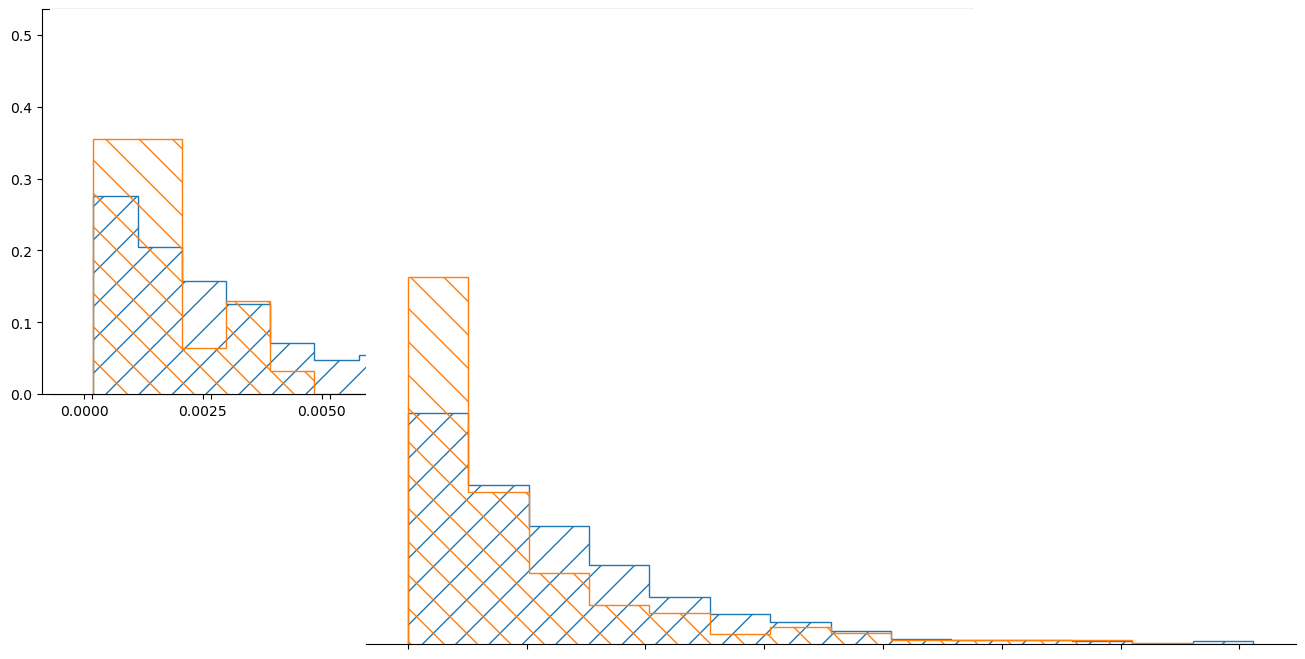

In [110]:
# z_tbl = z_mults_new
fig, ax = plt.subplots(figsize=(12, 5))

hatches = ["/", "\\"]

ax_arr = []
for i in range(2):#len(bins) - 1):
    z_bar = (bins[i] + bins[i + 1]) / 2
    ax_arr.append(fig.add_subplot(111, sharex=ax, sharey=ax))
    
    for tbl_num, z_tbl in enumerate([z_mults_old, z_mults_new]):
        # i = 0
        in_bin = (z_tbl["ZBEST_MEAN"] >= bins[i]) & (z_tbl["ZBEST_MEAN"] < bins[i + 1]) 

        if tbl_num == 0:
            std_bins = np.linspace(np.min(z_tbl["ZBEST_STD"][in_bin]), np.max(z_tbl["ZBEST_STD"][in_bin]), 15)

        w = np.ones_like(z_tbl["ZBEST_STD"][in_bin])
        w /= len(w)
                  
        ax_arr[i].hist(z_tbl["ZBEST_STD"][in_bin], bins=std_bins, histtype="step", weights=w, hatch=hatches[tbl_num])
        
    pos = ax_arr[i].get_position()
    new_pos = Bbox.from_bounds(z_bar, pos.y0 - 0.5 * i, pos.width, pos.height)
    ax_arr[i].set_position(new_pos)
    ax_arr[i].tick_params(labelleft=False, labelbottom=False, left=False)
    
    for sp in ["top", "right", "left"]:
        ax_arr[i].spines[sp].set_visible(False)